In [3]:
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY
import pandas as pd
import torch

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY , ZTF_TAXONOMY
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader

from src.exploringtools.InitCombinator import InitCombinator
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier
from src.layers.transformer.ATAT import TabularTransformer, LightCurveTransformer
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
order_classes = [
    "SNIa",
    "SNIbc",
    "SNIIb",
    "SNII",
    "SNIIn",
    "SLSN",
    "TDE",
    "Microlensing",
    "QSO",
    "AGN",
    "Blazar",
    "YSO",
    "CV/Nova",
    "LPV",
    "EA",
    "EB/EW",
    "Periodic-Other",
    "RSCVn",
    "CEP",
    "RRLab",
    "RRLc",
    "DSCT",
]



def get_confusion_matrix(mean_matrix, std_matrix, order_classes):
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=(13, 13)) #, dpi=110)
    im = ax.imshow(np.around(mean_matrix, decimals=2), interpolation='nearest', cmap=cmap)

    # color map
    new_color = cmap(1.0)

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    for i in range(mean_matrix.shape[0]):
        for j in range(mean_matrix.shape[1]):
            if mean_matrix[i, j] >= 0.005:
                #print(mean_matrix[i, j])
                text = f'{np.around(mean_matrix[i, j], decimals=2)}\n±{np.around(std_matrix[i, j], decimals=2)}'
                color = "white" if mean_matrix[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10.5)
            else:
                text = f'{np.around(mean_matrix[i, j], decimals=2)}'
                color = "white" if mean_matrix[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10.5)

    # Ajustes finales y mostrar la gráfica
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_xticks(np.arange(len(order_classes)))
    ax.set_yticks(np.arange(len(order_classes)))
    ax.set_xticklabels(order_classes)
    ax.set_yticklabels(order_classes)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13
    #plt.suptitle('asdf')
    plt.tight_layout()
    return fig
    plt.show()

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializati

True False False
Using checkpoint 33390.ckpt
Using checkpoint 33390.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


  0%|          | 0/594 [00:00<?, ?it/s]

100%|██████████| 594/594 [00:13<00:00, 42.96it/s]
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explici

True False False
Using checkpoint 25758.ckpt
Using checkpoint 25758.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


100%|██████████| 594/594 [00:14<00:00, 42.20it/s]


class_og_dataset_0


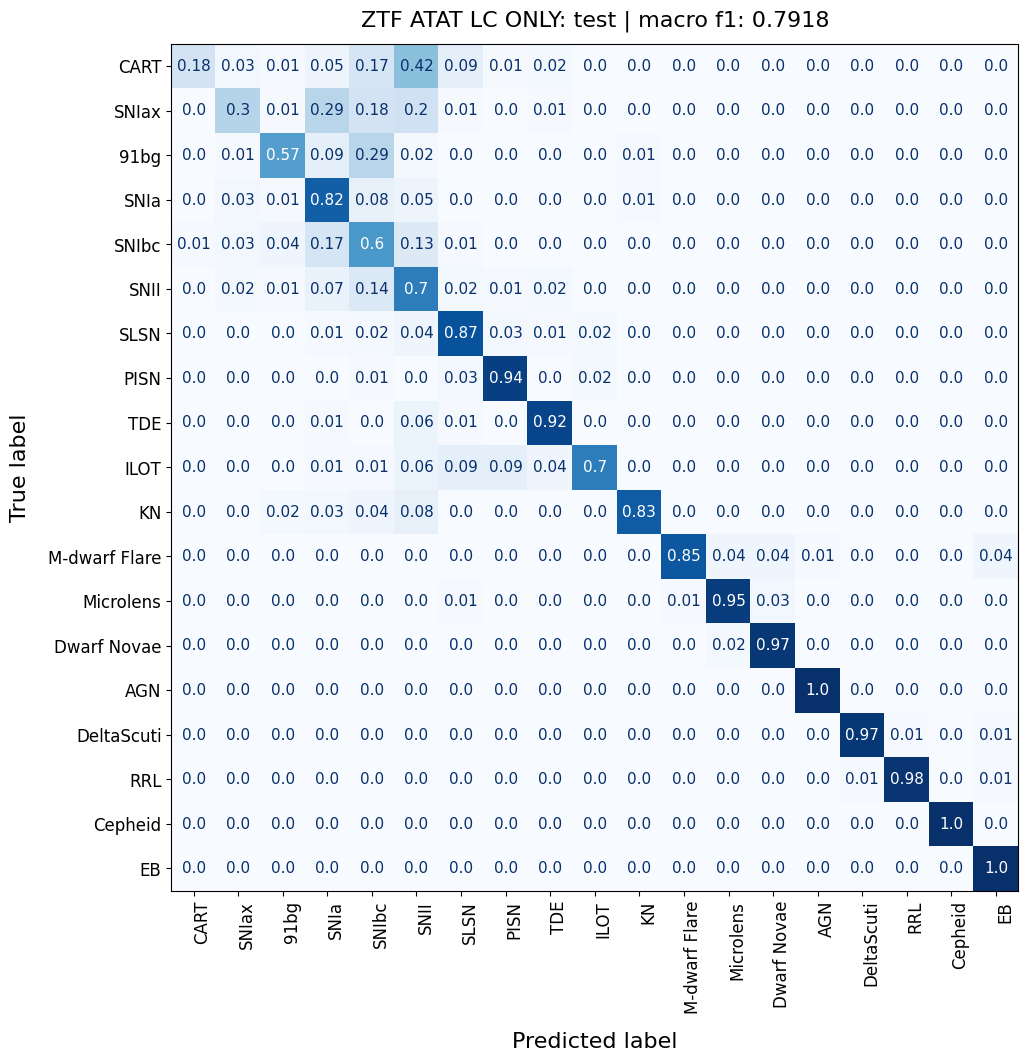

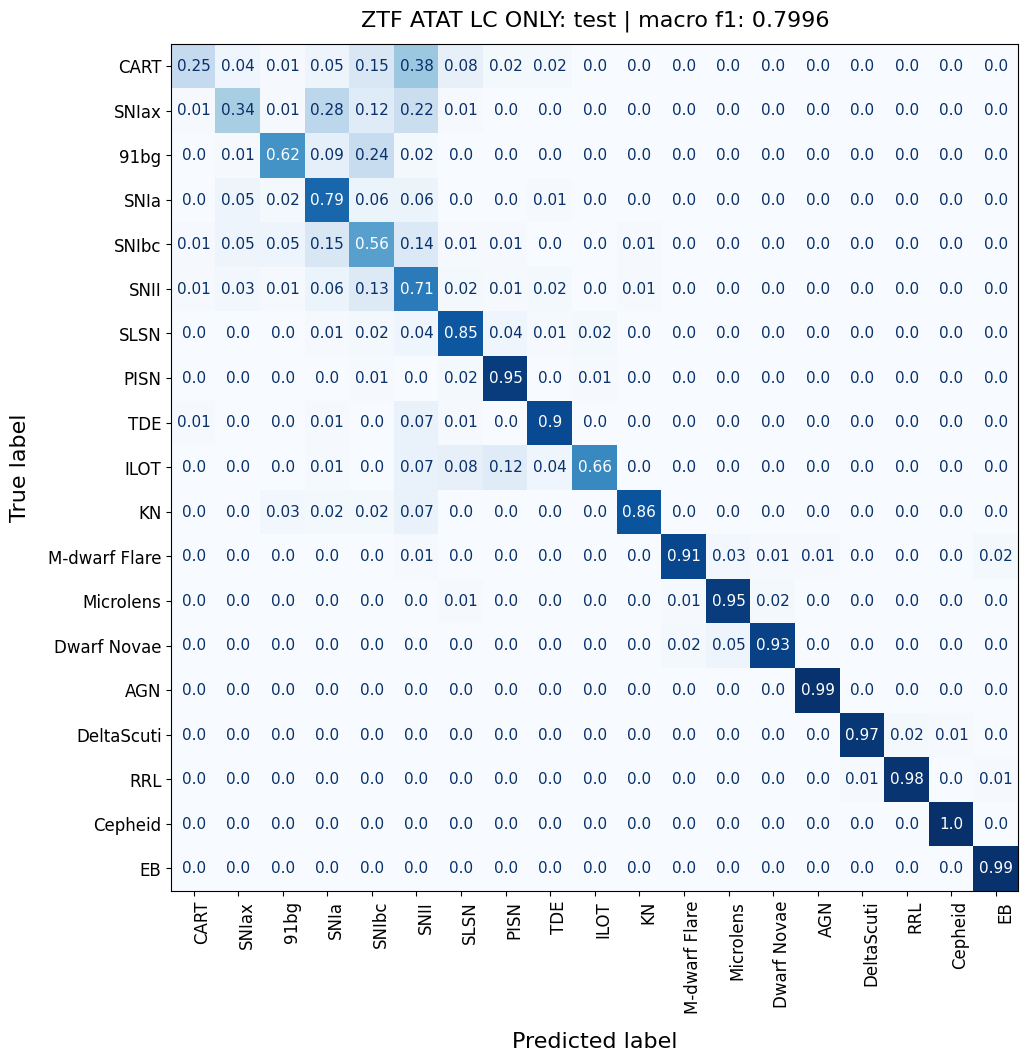

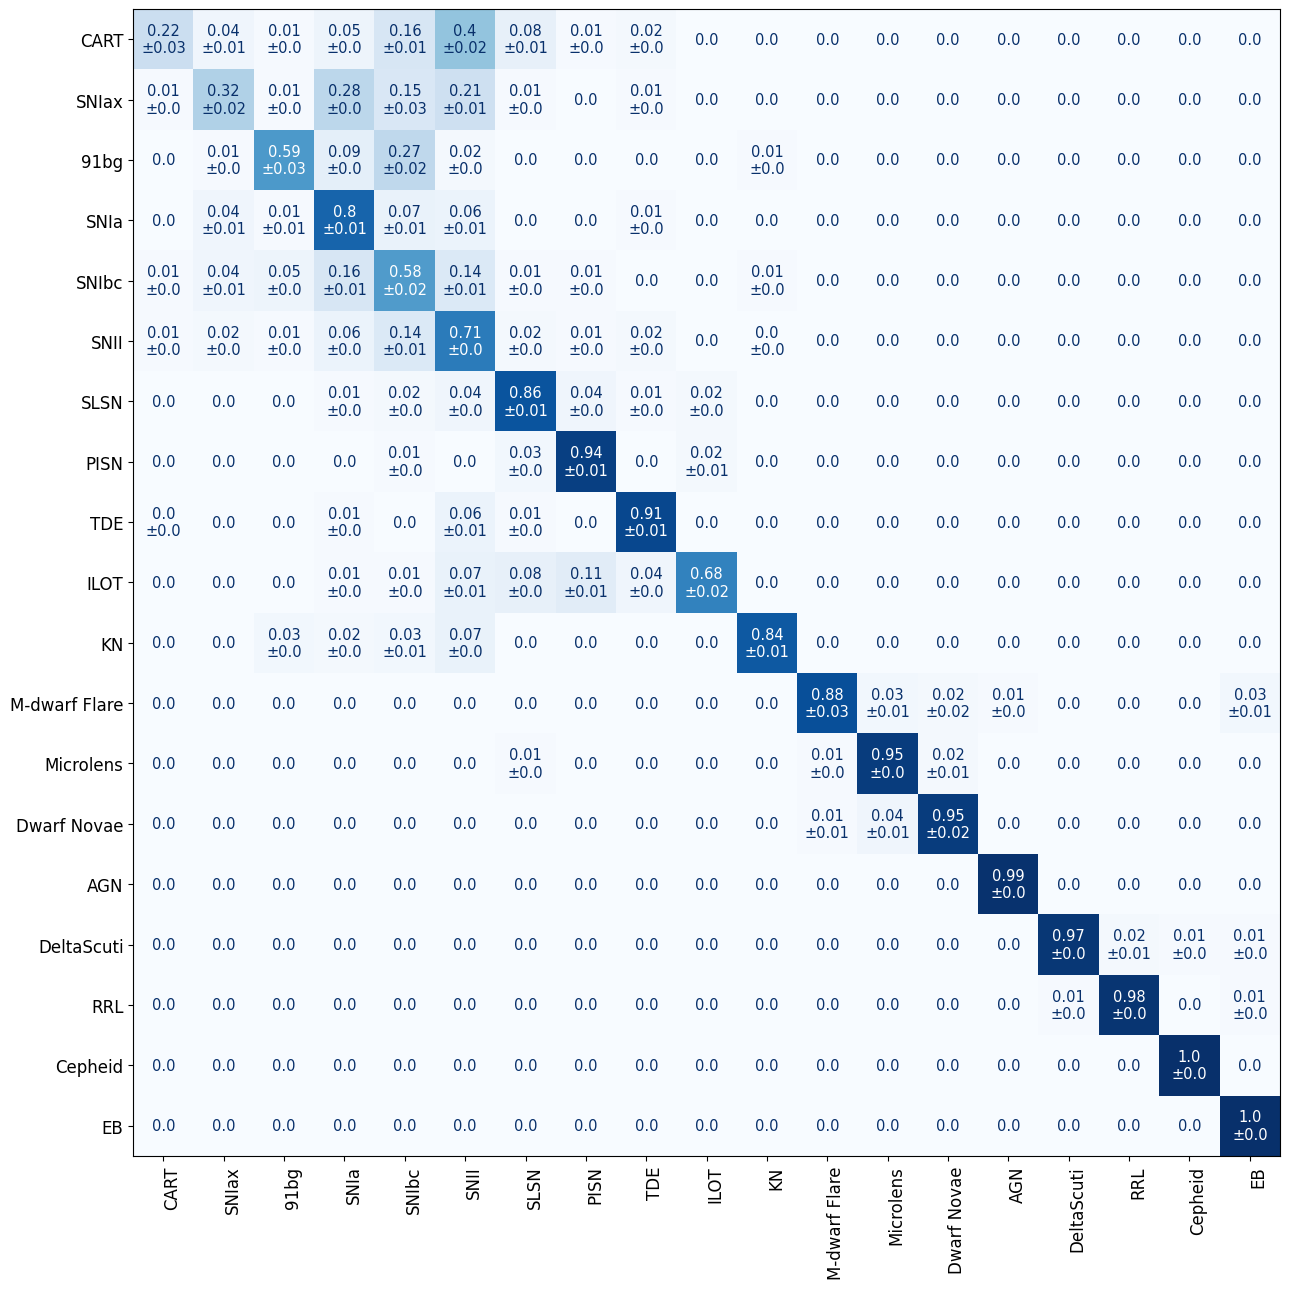

In [ ]:
FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"
#FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

DEVICE = 'cuda:0'
DATASET = 'test'
#FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'
TAXONOMY = ELASTICC_TAXONOMY
#TAXONOMY = ZTF_TAXONOMY

#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"

reports_1 = []
reports_2 = []
dfs = []
home = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/OLD_ELASTICC/LC/'


paths = [home + f'class_og_dataset_{i}' + '/' for i in range(2)]
for PATH in paths:

    test = InitClassifier(path_to_config_yaml=PATH,
                      model= LightCurveTransformer,
                      classifier = MultimodalClassifier,
                      use_lc = True,
                      arg_key='lc')
    backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
    classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
    test.load_backbone_weights(backbone_od)
    test.load_classifier_weights(classifier_od)
    test.args.datamodule.val_use_sampler = False
    dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)
    dl.init_test_dataset()


    val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
    #print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
    dfs.append(pd.DataFrame(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(TAXONOMY().keys()),digits = 4, output_dict=True)).T.drop(columns = ['support']))

    test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=order_classes)

    for_cm_true = np.vectorize({value:key for key, value in TAXONOMY().items()}.get)([int(x) for x in val_true])
    for_cm_pred = np.vectorize({value:key for key, value in TAXONOMY().items()}.get)([int(x) for x in np.argmax(val_preds, axis = -1)])
    reports_1.append((for_cm_true,for_cm_pred ))

matrices = []
for y_test, y_pred in reports_1:
    cm = confusion_matrix(y_test, y_pred,

                            labels=order_classes, normalize='true')
    matrices.append(cm)

# Calculando la media y la desviación estándar
mean_matrix_lc_md_feat = np.mean(matrices, axis=0)
std_matrix_lc_md_feat = np.std(matrices, axis=0)

fig = get_confusion_matrix(mean_matrix_lc_md_feat, std_matrix_lc_md_feat, order_classes)
#plt.show()
name = paths[0].split('/')[-2]
print(name)
fig.savefig("MATRICES/" + f"{name}.png")  # save before plt.show()


In [12]:
dfs

[]

In [11]:
reports_1.pop(-1)

(array(['SNII', 'SNII', 'SNII', ..., 'CART', 'CART', 'CART'], dtype='<U13'),
 array(['Cepheid', 'DeltaScuti', 'DeltaScuti', ..., 'DeltaScuti',
        'DeltaScuti', 'Cepheid'], dtype='<U13'))

In [15]:
reports_1

[(array(['SNII', 'SNII', 'SNII', ..., 'CART', 'CART', 'CART'], dtype='<U13'),
  array(['Microlens', 'Microlens', 'Microlens', ..., 'Microlens',
         'Microlens', 'Microlens'], dtype='<U13')),
 (array(['SNII', 'SNII', 'SNII', ..., 'CART', 'CART', 'CART'], dtype='<U13'),
  array(['SLSN', 'TDE', 'TDE', ..., 'Microlens', 'TDE', 'SNIax'],
        dtype='<U11'))]

In [14]:
import pandas as pd

means = pd.concat([df.reset_index() for df in dfs]).groupby('index').mean()

In [15]:
stds = pd.concat([df.reset_index() for df in dfs]).groupby('index').std()


In [16]:
means.reset_index()

,index,precision,recall,f1-score
0,91bg,0.831086,0.594500,0.692524
1,AGN,0.989548,0.993000,0.991266
2,CART,0.867828,0.218500,0.347687
3,Cepheid,0.992534,0.997000,0.994762
4,DeltaScuti,0.981766,0.969000,0.975339
5,Dwarf Novae,0.952289,0.950500,0.950953
6,EB,0.950630,0.996500,0.972957
7,ILOT,0.928907,0.682000,0.786262
8,KN,0.967261,0.842000,0.900232
9,M-dwarf Flare,0.975528,0.881000,0.925370


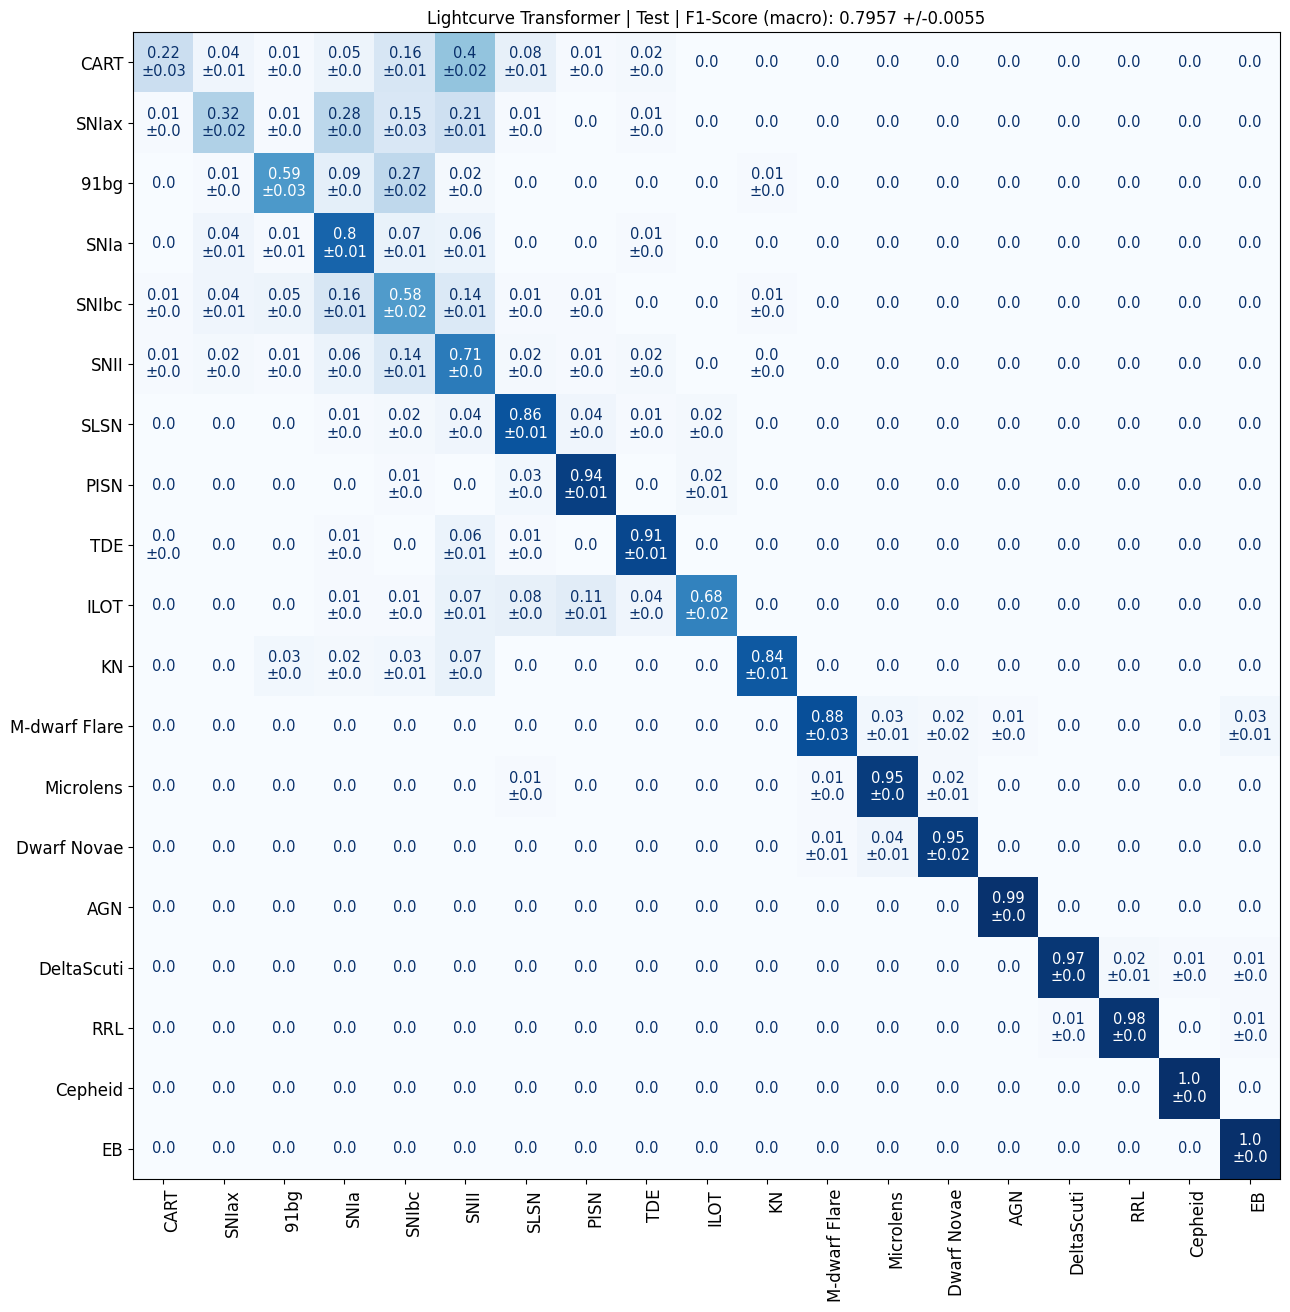

In [17]:

matrices = []
for y_test, y_pred in reports_1:
    cm = confusion_matrix(y_test, y_pred,

                            labels=order_classes, normalize='true')
    matrices.append(cm)

# Calculando la media y la desviación estándar
mean_matrix_lc_md_feat = np.mean(matrices, axis=0)
std_matrix_lc_md_feat = np.std(matrices, axis=0)

fig = get_confusion_matrix(mean_matrix_lc_md_feat, std_matrix_lc_md_feat, order_classes)
plt.title(f'Lightcurve Transformer | Test | F1-Score (macro): {means.iloc[20]['f1-score'].round(4).astype(str) +' +/-'+ stds.iloc[20]['f1-score'].round(4).astype(str)}')
#plt.show()
name = paths[0].split('/')[-2]

fig.savefig("MATRICES/" + f"{name}.png")  # save before plt.show()